In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

import sys
sys.path.append("../code")
import households as hh

In [2]:
# matplotlib settings
mpl.rcParams["axes.spines.right"] = False
mpl.rcParams["axes.spines.top"] = False
mpl.rcParams["axes.titlesize"]= 8
mpl.rcParams["xtick.labelsize"] = 8
mpl.rcParams["ytick.labelsize"] = 8
mpl.rcParams["axes.labelsize"] = 10
mpl.rcParams["legend.fontsize"] = 7
mpl.rcParams["legend.title_fontsize"] = 7
mpl.rcParams["font.family"] = "Helvetica"
cm = 1/2.54

In [3]:
data = pd.read_csv('../data/processed/(gamma=0.85,ah=0.2,europe_as_country)_data.csv', index_col=0)
data_g07 = pd.read_csv('../data/processed/(gamma=0.7,ah=0.2,europe_as_country)_data.csv', index_col=0)
data_g1 = pd.read_csv('../data/processed/(gamma=1,ah=0.2,europe_as_country)_data.csv', index_col=0)

data_a = pd.read_csv('../data/processed/(gamma=0.85,ah=0.2,europe_as_country)_data_a.csv', index_col=0)

data_a_g07 = pd.read_csv('../data/processed/(gamma=0.7,ah=0.2,europe_as_country)_data_a.csv', index_col=0)
data_a_g1 = pd.read_csv('../data/processed/(gamma=1,ah=0.2,europe_as_country)_data_a.csv', index_col=0)

data_a_ah18 = pd.read_csv('../data/processed/(gamma=0.85,ah=0.18,europe_as_country)_data_a.csv', index_col=0)
data_a_ah22 = pd.read_csv('../data/processed/(gamma=0.85,ah=0.22,europe_as_country)_data_a.csv', index_col=0)

data_a_basicmean = pd.read_csv('../data/processed/(gamma=0.85,ah=0.2,basic_mean)_data_a.csv', index_col=0)
data_a_weightedmean = pd.read_csv('../data/processed/(gamma=0.85,ah=0.2,weighted_mean)_data_a.csv', index_col=0)

In [4]:
# short helper function to calculate the explained variance
def calc_ev(data, data_a):
    r2 = np.zeros(len(data.index))
    for i in range(len(data.index)):
        r2[i] = hh.calc_explained_variance(data.iloc[i], data_a.iloc[i])
    return r2

In [5]:
r2 = calc_ev(data, data_a)
r2_g07 = calc_ev(data_g07, data_a_g07)
r2_g1 = calc_ev(data_g1, data_a_g1)
r2_ah18 = calc_ev(data, data_a_ah18)
r2_ah22 = calc_ev(data, data_a_ah22)
r2_basicmean = calc_ev(data, data_a_basicmean)
r2_weightedmean = calc_ev(data, data_a_weightedmean)

In [6]:
rs = (data - data_a).values.flatten()
rs_g07 = (data_g07 - data_a_g07).values.flatten()
rs_g1 = (data_g1 - data_a_g1).values.flatten()
rs_ah18 = (data - data_a_ah18).values.flatten()
rs_ah22 = (data - data_a_ah22).values.flatten()
rs_basicmean = (data - data_a_basicmean).values.flatten()
rs_weightedmean = (data - data_a_weightedmean).values.flatten()

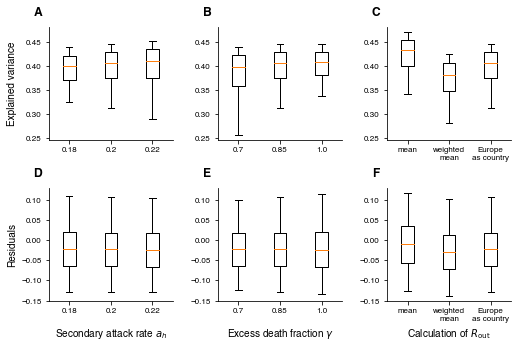

In [7]:
fig = plt.figure(figsize=(18.*cm, 12*cm), constrained_layout=True)
grid = fig.add_gridspec(ncols=3, nrows=2, wspace=0.1)
ax1 = fig.add_subplot(grid[0,0])
ax2 = fig.add_subplot(grid[0,1], sharey=ax1)
ax3 = fig.add_subplot(grid[0,2], sharey=ax1)
ax4 = fig.add_subplot(grid[1,0])
ax5 = fig.add_subplot(grid[1,1], sharey=ax4)
ax6 = fig.add_subplot(grid[1,2], sharey=ax4)

boxparams = {'whis':[10,90], 'showfliers':False}

ax1.boxplot([r2_ah18,r2,r2_ah22], labels=[0.18,0.2,0.22], **boxparams)
ax2.boxplot([r2_g07,r2,r2_g1], labels=[0.7,0.85,1.0], **boxparams)
ax3.boxplot([r2_basicmean,r2_weightedmean,r2], labels=['mean','weighted\nmean','Europe\nas country'], **boxparams)

ax4.boxplot([rs_ah18,rs,rs_ah22], labels=[0.18,0.2,0.22], **boxparams)
ax5.boxplot([rs_g07,rs,rs_g1], labels=[0.7,0.85,1.0], **boxparams)
ax6.boxplot([rs_basicmean,rs_weightedmean,rs], labels=['mean','weighted\nmean','Europe\nas country'], **boxparams)

ax1.set_ylabel(r'Explained variance')
ax4.set_ylabel(r'Residuals')
ax4.set_xlabel(r'Secondary attack rate $a_h$')
ax5.set_xlabel(r'Excess death fraction $\gamma$')
ax6.set_xlabel(r'Calculation of $R_\mathrm{out}$')

ax1.text(-.12,1.1, 'A', size=12, weight='bold', color='black', transform=ax1.transAxes)
ax2.text(-.12,1.1, 'B', size=12, weight='bold', color='black', transform=ax2.transAxes)
ax3.text(-.12,1.1, 'C', size=12, weight='bold', color='black', transform=ax3.transAxes)
ax4.text(-.12,1.1, 'D', size=12, weight='bold', color='black', transform=ax4.transAxes)
ax5.text(-.12,1.1, 'E', size=12, weight='bold', color='black', transform=ax5.transAxes)
ax6.text(-.12,1.1, 'F', size=12, weight='bold', color='black', transform=ax6.transAxes)

fig.align_labels()

fig.savefig('../figures/figure_S6.pdf')